This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

!pip install keras-nightly keras-hub-nightly --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
from IPython.core.interactiveshell import InteractiveShell # make all output in ipython show, not just last line
InteractiveShell.ast_node_interactivity = "all"   # pretty print all cell's output and not just the last one

### A brief history of deep learning frameworks

In the real world, you’re not going to be writing low-level code from scratch like we did at
the end of Chapter 2. Instead, you’re going to use a framework. Besides Keras, the main
deep learning frameworks today are JAX, TensorFlow, and PyTorch. This book will teach you
about all four.

If you’re just getting started with deep learning in 2025, it may seem like all these
frameworks have been here forever. In reality, they’re all quite recent, with Keras being the
oldest among the four (launched in March 2015). The ideas behind these frameworks,
however, have a long history – the first paper about automatic differentiation was published
in 1964 (Wengert - A Simple Automatic Derivative Evaluation Program, Communications of
the ACM, Volume 7 / Number 8 / August, 1964).

All these frameworks combine three key features:

1. A way to compute gradients for arbitrary differentiable functions
(automatic differentiation).

2. A way to run tensor computations on CPU and GPU (and possibly even on
other specialized deep learning hardware).


3. A way to distribute computation across multiple devices or multiple
computers, such as multiple GPUs on one computer, or even multiple
GPUs across multiple separate computers.


Together, these three simple features unlock all modern deep learning.

It took a long time for the field to develop robust solutions for all three problems and
package those solutions in a reusable form. Since its inception in the 1960s and until the
2000s, autodifferentiation had no practical applications in machine learning – folks who
worked with neural networks simply wrote their own gradient logic by hand, usually in a
language like C++. Meanwhile, GPU programming was all but impossible.

Things started to slowly change in the late 2000s. First, Python and its ecosystem were
slowly rising in popularity in the scientific community, gaining traction over Matlab and
C++. Second, NVIDIA released CUDA in 2006, unlocking the possibility of building neural
networks that could run on consumer GPUs. The initial focus on CUDA was on physics
simulation rather than machine learning, but that didn’t stop machine learning researchers
from starting to implement CUDA-based neural networks from 2009 onwards. They were
typically one-off implementations that ran on a single GPU without any autodifferentiation.

The first framework to enable autodifferentiation and GPU computation to train deep
learning models was Theano, circa 2009. Theano is the conceptual ancestor of all modern
deep learning tools. It started getting good traction in the machine learning research
community in 2013-2014, after the results of the ImageNet 2012 competition ignited the
world’s interest in deep learning. Around the same time, a few other GPU-enabled deep
learning libraries started gaining popularity in the computer vision world, in particular Torch
7 (Lua-based) and Caffe (C++-based). Keras launched in early 2015 as a higher-level,
easier-to-use deep learning library powered by Theano, and it quickly gained traction with
the few thousands of people who were into deep learning at the time.

Then in late 2015, Google launched TensorFlow, which took many of the key ideas from
Theano and added support for large-scale distributed computation. The release of
TensorFlow was a watershed moment that precipitated deep learning in the mainstream
developer zeitgeist. Keras immediately added support for TensorFlow. By mid-2016, over
half of all TensorFlow users were using it through Keras.

In response to TensorFlow, Meta (named Facebook at the time) launched PyTorch about
one year later, taking ideas from Chainer (a niche but innovative framework launched in
mid-2015, now long dead) and NumPy-Autograd, a CPU-only autodifferentiation library for
NumPy released by Maclaurin et al. in 2014. Meanwhile, Google released TPUs as an
alternative to GPUs, alongside XLA, a high-performance compiler developed to enable
TensorFlow to run on TPUs.

A few years later, at Google, Matthew Johnson – one of the developers who worked on
NumPy-Autograd – released JAX as an alternative way to use autodifferentiation with XLA.
JAX quickly gained traction with researchers thanks to its minimalistic API and high
scalability. Today, Keras, TensorFlow, PyTorch, and JAX are the top frameworks in the deep
learning world.

Looking back on this chaotic history, we can ask – what’s next? Will a new framework
arise tomorrow? Will we switch to a new programming language, or a new hardware
platform?

If you ask me, three things today are certain:
1. Python has won. Its machine learning and data science ecosystem simply
has too much momentum at this point. There won’t be a brand new
language to replace it – at least not in the next 15 years.
2. We’re in a multiframework world – all four frameworks are wellestablished
and are unlikely to go anywhere in the next few years. It’s a
good idea for you to learn a little bit about each one. However, it’s highly
possible that new frameworks will gain popularity in the future, in
addition to them – Apple’s recently released MLX could be one such
example. In this context, using Keras is a considerable advantage: you
should be able to run your existing Keras models on any new up-andcoming
framework, via a new Keras backend. Keras will keep providing
future-proof stability to machine learning developers in the future, like it
has since 2015 – back when neither TensorFlow, PyTorch, nor JAX
existed.
3. New chips may certainly arise in the future, alongside NVIDIA’s GPUs and
Google’s TPUs. For instance, AMD’s GPU line has likely bright days ahead.
But any new such chip will have to work with the existing frameworks in
order to gain traction. New hardware is unlikely to disrupt your
workflows.

### How these frameworks relate to each other

Keras, TensorFlow, PyTorch, and JAX don’t all have the same feature set and aren’t
interchangeable. They have some overlap, but to a large extent they serve different roles
for different use cases. The biggest difference is between Keras and the three others. Keras
is a high-level framework, while the others are lower-level. Imagine building a house. Keras
is like a prefabricated building kit: it provides a streamlined interface for setting up and
training neural networks. In contrast, TensorFlow, PyTorch, and JAX are like the raw
materials used in construction.

As you saw in the previous chapters, training a neural network revolves around the
following concepts:

First, low-level tensor manipulation – the infrastructure that underlies all modern
machine learning. This translates to low-level APIs found in TensorFlow, PyTorch [1], and
JAX:

Tensors, including special tensors that store the network’s state
(variables)

Tensor operations such as addition, relu, or matmul

Backpropagation, a way to compute the gradient of mathematical
expressions

Second, high-level deep learning concepts. This translates to Keras APIs:

Layers, which are combined into a model

A loss function, which defines the feedback signal used for learning

An optimizer, which determines how learning proceeds

Metrics to evaluate model performance, such as accuracy

A training loop that performs mini-batch stochastic gradient descent

Further, Keras is unique in that it isn’t a fully standalone framework. It needs a backend
engine to run (see Figure 3.4), much like a prefabricated housebuilding kit needs to source
building materials from somewhere. TensorFlow, PyTorch, and JAX can all be used as Keras
backends. In addition, Keras can run on NumPy, but since NumPy does not provide an API
for gradients, Keras workflows on NumPy are restricted to making predictions from a model
– training is impossible.

Now that you have a clearer understanding of how all these frameworks came to be and
how they relate to each other, let’s dive into what it’s like to work with them. We’ll cover
them in chronological order: TensorFlow first, then PyTorch, and finally JAX.

### Introduction to TensorFlow

TensorFlow is a Python-based open-source machine learning framework developed primarily
by Google. Its initial release was in November 2015, followed by a v1 release in February
2017, and a v2 release in October 2019. TensorFlow is heavily used in production-grade
machine learning applications across the industry.
It’s important to keep in mind that TensorFlow is more than a single library. It’s really a
platform, home to a vast ecosystem of components, some developed by Google, some
developed by third parties. For instance, there’s TFX for industry-strength machine learning
workflow management, TF-Serving for production deployment, the TF Optimization Toolkit
for model quantization and pruning, and TFLite and MediaPipe for mobile application
deployment.
Together, these components cover a very wide range of use cases, from cutting-edge
research to large-scale production applications.

#### First steps with TensorFlow

Over the next paragraphs, you’ll get familiar with all the basics of TensorFlow. We’ll cover
the following key concepts:

Tensors and Variables

Numerical operations in TensorFlow

Computing gradients with a GradientTape

Making TensorFlow functions fast by leveraging Just-In-Time compilation

We’ll then conclude the introduction with an end-to-end example: a pure-TensorFlow
implementation of linear regression.
Let’s get those tensors flowing.

##### Tensors and Variables in TensorFlow

#### Constant tensors

To do anything in TensorFlow, we’re going to need some tensors.
Tensors need to be created with some initial value, so common ways to create tensors
are via tf.ones (equivalent to np.ones) and tf.zeros (equivalent to np.zeros). You can
also create a tensor from Python or NumPy values using tf.constant.

In [ ]:
import tensorflow as tf
tf.ones(shape=(2, 1))  # same as np.ones(shape=(2,1))

2025-07-22 15:36:41.152329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753198601.166619   16878 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753198601.170838   16878 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753198601.181945   16878 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753198601.181971   16878 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753198601.181972   16878 computation_placer.cc:177] computation placer alr

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [ ]:
tf.zeros(shape=(2, 1))  # same as np.zeros(shape=(2,1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [4]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

#### Random tensors

Note that setting the random seed is not the same as python or numpy:
tf.random.set_seed(42)

In [5]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[ 5.6482077e-05]
 [-1.0786296e+00]
 [-5.5148029e-01]], shape=(3, 1), dtype=float32)


In [ ]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)  # uniform distribution between 0 and 1
print(x)

tf.Tensor(
[[0.23686087]
 [0.9556216 ]
 [0.4993863 ]], shape=(3, 1), dtype=float32)


##### Tensor assignment and the Variable class

A significant difference between NumPy arrays and TensorFlow tensors is that TensorFlow
tensors aren’t assignable: they’re constant. For instance, in NumPy, you can do:

In [7]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

This will fail in tensorflow:

x = tf.ones(shape=(2, 2))

x[0, 0] = 0.0 

In [ ]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))  # mean zero, sd=1
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.8852332 ],
       [-0.28284281],
       [-0.3071367 ]], dtype=float32)>


You can use the assign method to change values in an array

In [9]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [10]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [11]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

##### Tensor operations: doing math in TensorFlow

In [ ]:
a = tf.ones((2, 2))
b = tf.square(a)  # a**2
c = tf.sqrt(a)  # a**(1/2)
d = b + c
e = tf.matmul(a, b) # dot product
f = tf.concat((a, b), axis=0)  # concat along axis zero

Here’s an equivalent of the dense layer we saw in Chapter 2:

In [13]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### Gradients in TensorFlow: a second look at the `GradientTape` API

So far, TensorFlow seems to look a lot like NumPy. But here’s something NumPy can’t do:
retrieve the gradient of any differentiable expression with respect to any of its inputs. Just
open a GradientTape scope, apply some computation to one or several input tensors, and
retrieve the gradient of the result with respect to the inputs.

In [14]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

This is most commonly used to retrieve the gradients of the loss of a model with respect to
its weights: gradients = tape.gradient(loss, weights).
In Chapter 2, you’ve seen how the GradientTape works on either a single input or a list
of inputs, and how inputs could be either scalars or high-dimensional tensors.

So far, you’ve only seen the case where the input tensors in tape.gradient() were
TensorFlow variables. It’s actually possible for these inputs to be any arbitrary tensor.
However, only trainable variables are being tracked by default.

With a constant tensor, you’d have to manually mark it as being tracked, by calling
tape.watch() on it:

In [15]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

Why? Because it would be too expensive to preemptively store the information required to
compute the gradient of anything with respect to anything. To avoid wasting resources, the
tape needs to know what to watch. Trainable variables are watched by default because
computing the gradient of a loss with regard to a list of trainable variables is the most
common use case of the gradient tape.

The gradient tape is a powerful utility, even capable of computing second-order
gradients, that is to say, the gradient of a gradient. For instance, the gradient of the
position of an object with regard to time is the speed of that object, and the second-order
gradient is its acceleration.

If you measure the position of a falling apple along a vertical axis over time, and find
that it verifies position(time) = 4.9 * time ** 2, what is its acceleration? Let’s use two
nested gradient tapes to find out.

In [ ]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2  # formula is s = 1/2 * g * t^2
    speed = inner_tape.gradient(position, time)  # speed is first derivative of position
acceleration = outer_tape.gradient(speed, time)  # acceleration is second derivative of position

##### Making TensorFlow functions fast using compilation

All the TensorFlow code you’ve written so far has been executing “eagerly”. This means
operations are executed one after the other in the Python runtime, much like any Python
code, or like NumPy code. Eager execution is great for debugging, but it is typically quite
slow. It can often be beneficial to parallelize some computation, or “fuse” operations –
replacing two consecutive operations, like matmul followed by relu, with a single, more
efficient operation that does the same thing without materializing the intermediate output.
This can be achieved via compilation. The general idea of compilation is to take certain
functions you’ve written in Python, lift them out of Python, automatically rewrite them into
a faster and more efficient “compiled program,” and then call that program from the Python
runtime.

The main benefit of compilation is improved performance. There’s a drawback too: the
code you write is no longer the code that gets executed, which can make the debugging
experience painful. Only turn on compilation after you’ve already debugged your code in
the Python runtime.

You can apply compilation to any TensorFlow function by wrapping it in a tf.function
decorator, like this:

In [17]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

When you do this, any call to dense() is replaced with a call to a compiled program that
implements a more optimized version of the function. The first call to the function will take
a bit longer, because TensorFlow will be compiling your code. This only happens once – all
subsequent calls to the same function will be fast.

TensorFlow has two compilation modes:

First, the default one, which we refer to as “graph mode”. Any function
decorated with @tf.function runs in graph mode.

Second, compilation with XLA, a high performance compiler for ML (it’s
short for Accelerated Linear Algebra). You can turn it on by specifying
jit_compile=True, like this:

In [18]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

It is often the case that compiling a function with XLA will make it run faster than graph
mode – though it takes more time to execute the function the first time, since the compiler
has more work to do.

#### An end-to-end example: a linear classifier in pure TensorFlow

You know about tensors, variables, tensor operations, and you know how to compute
gradients. That’s enough to build any TensorFlow-based machine learning model based on
gradient descent. Let’s walk through an end-to-end example to make sure everything is
crystal clear.

In a machine learning job interview, you may be asked to implement a linear classifier
from scratch: a very simple task that serves as a filter between candidates who have some
minimal machine learning background, and those who don’t. Let’s get you past that filter,
and use your newfound knowledge of TensorFlow to implement such a linear classifier.
First, let’s come up with some nicely linearly separable synthetic data to work with: two
classes of points in a 2D plane.

In [ ]:
import numpy as np

num_samples_per_class = 1000  # 1000 samples per class, each class has a mean and covariance.  The covariance makes an oval cloud
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [ ]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)  # stack the negative and positive points into (2000,2) array

In [ ]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)  # generate target labels

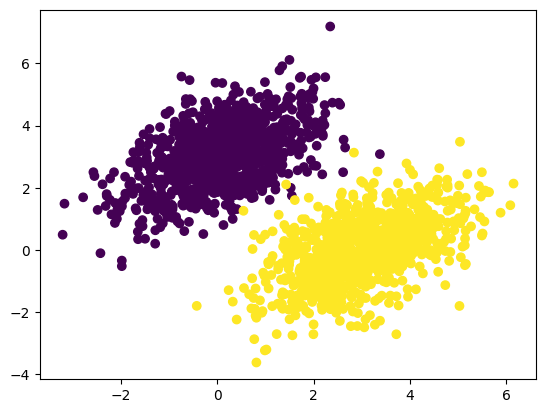

In [22]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.savefig("linear_model_inputs.png", dpi=300)

Now, let’s create a linear classifier that can learn to separate these two blobs. A linear
classifier is an affine transformation (prediction = matmul(input, W) + b) trained to
minimize the square of the difference between predictions and the targets.

As you’ll see, it’s actually a much simpler example than the end-to-end example of a toy
two-layer neural network from the end of Chapter 2. However, this time, you should be able
to understand everything about the code, line by line.

Let’s create our variables W and b, initialized with random values and with zeros
respectively:

In [ ]:
input_dim = 2  # 2D points
output_dim = 1  # 0 or 1 on the output to designate class
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

Forward pass function

In [24]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

Because our linear classifier operates on 2D inputs, W is really just two scalar coefficients: W
= [[w1], [w2]]. Meanwhile, b is a single scalar coefficient. As such, for given input point
[x, y], its prediction value is:

 prediction = [[w1], [w2]] • [x, y] + b = w1 * x + w2 * y + b.

Here’s our loss function:

In [ ]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)  # same shape as predictions and targets
    return tf.reduce_mean(per_sample_losses)  # compute average loss

Now, the training step, which receives some training data and updates the weights W and b
so as to minimize the loss on the data:

In [ ]:
learning_rate = 0.1

@tf.function(jit_compile=True)  # speed up runtime, but slower to start
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:  # forward pass inside the tape scope
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])  # get the gradient with respect to W and b
    W.assign_sub(grad_loss_wrt_W * learning_rate)  # W -= gradient times learning rate
    b.assign_sub(grad_loss_wrt_b * learning_rate)  # b -= gradient times learning rate
    return loss

For simplicity, we’ll do batch training instead of mini-batch training: we’ll run each training
step (gradient computation and weight update) on the entire data, rather than iterate over
the data in small batches. On one hand, this means that each training step will take much
longer to run, since we compute the forward pass and the gradients for 2,000 samples at
once. On the other hand, each gradient update will be much more effective at reducing the
loss on the training data, since it will encompass information from all training samples
instead of, say, only 128 random samples. As a result, we will need much fewer steps of
training, and we should use a larger learning rate than what we would typically use for
mini-batch training (we’ll use learning_rate = 0.1, defined above).

In [27]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

I0000 00:00:1753198608.527902   16878 service.cc:152] XLA service 0x22016c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753198608.527985   16878 service.cc:160]   StreamExecutor device (0): Quadro T2000, Compute Capability 7.5
I0000 00:00:1753198608.552170   16878 cuda_dnn.cc:529] Loaded cuDNN version 91100


Loss at step 0: 1.3823
Loss at step 1: 0.2907
Loss at step 2: 0.1362
Loss at step 3: 0.1054
Loss at step 4: 0.0950
Loss at step 5: 0.0883
Loss at step 6: 0.0828
Loss at step 7: 0.0778
Loss at step 8: 0.0732
Loss at step 9: 0.0690
Loss at step 10: 0.0652
Loss at step 11: 0.0618
Loss at step 12: 0.0586
Loss at step 13: 0.0557
Loss at step 14: 0.0531
Loss at step 15: 0.0507
Loss at step 16: 0.0485
Loss at step 17: 0.0465
Loss at step 18: 0.0446
Loss at step 19: 0.0430
Loss at step 20: 0.0414
Loss at step 21: 0.0401
Loss at step 22: 0.0388
Loss at step 23: 0.0376
Loss at step 24: 0.0366
Loss at step 25: 0.0356
Loss at step 26: 0.0347
Loss at step 27: 0.0339
Loss at step 28: 0.0332
Loss at step 29: 0.0325
Loss at step 30: 0.0319
Loss at step 31: 0.0314
Loss at step 32: 0.0309
Loss at step 33: 0.0304
Loss at step 34: 0.0300
Loss at step 35: 0.0296
Loss at step 36: 0.0292
Loss at step 37: 0.0289
Loss at step 38: 0.0286
Loss at step 39: 0.0283


I0000 00:00:1753198608.809481   16878 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


After 40 steps, the training loss seems to have stabilized around 0.025. Let’s plot how our
linear model classifies the training data points. Because our targets are zeros and ones, a
given input point will be classified as “0” if its prediction value is below 0.5, and as “1” if it
is above 0.5:

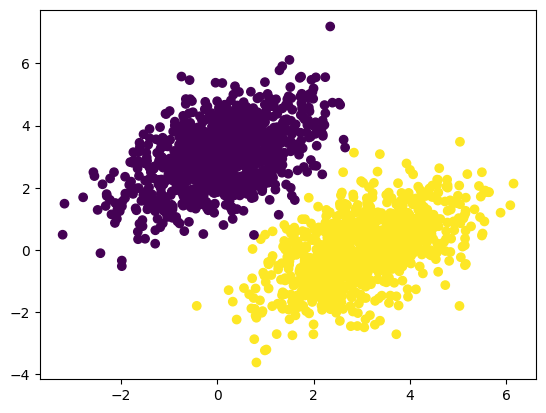

In [28]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.savefig("linear_model_predictions.png", dpi=300)

Recall that the prediction value for a given point [x, y] is simply prediction == [[w1],
[w2]] • [x, y] + b == w1 * x + w2 * y + b. Thus, class “0” is defined as: w1 * x +
w2 * y + b < 0.5 and class “1” is defined as: w1 * x + w2 * y + b > 0.5. You’ll notice
that what you’re looking at is really the equation of a line in the 2D plane: w1 * x + w2 *
y + b = 0.5. Above the line, class 1, below the line, class 0. You may be used to seeing
line equations in the format y = a * x + b; in the same format, our line becomes: y = -
w1 / w2 * x + (0.5 - b) / w2.

Let’s plot this line:

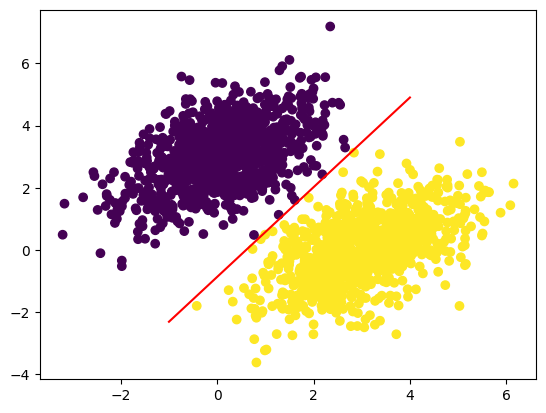

In [29]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

This is really what a linear classifier is all about: finding the parameters of a line (or, in
higher-dimensional spaces, a hyperplane) neatly separating two classes of data.

#### What makes the TensorFlow approach unique

You’re now familiar with all the basic APIs that underlie TensorFlow-based workflows – and
you’re about to dive into more frameworks, in particular PyTorch and JAX. What makes
working with TensorFlow different from working with any other framework? When should
you use TensorFlow, and when should you use something else?
If you ask me, here are the main benefits of TensorFlow:

Thanks to graph mode and XLA compilation, it’s fast. It’s usually
significantly faster than PyTorch and NumPy, though JAX is often even
faster.

It is extremely feature-complete. Unique among all frameworks, it has
support for string tensors as well as “ragged tensors” (tensors where
different entries may have different dimensions – very useful for handling
sequences without requiring to pad them to a shared length). It also has
outstanding support for data preprocessing, via the highly performant
tf.data API. tf.data is so good that even JAX recommends it for data
preprocessing. Whatever you need to do, TensorFlow has a solution for it.

Its ecosystem for production deployment is the most mature among all
frameworks, especially when it comes to deploying on mobile or in the
browser.

However, TensorFlow also has some noticeable flaws:

It has a sprawling API – the flipside of being very feature-complete.
TensorFlow includes thousands of different operations.

Its numerical API is occasionally inconsistent with the NumPy API, making
it a bit harder to approach if you’re already familiar with NumPy.

The popular pretrained model sharing platform HuggingFace has less
support for TensorFlow, which means that the latest generative AI models
may not always be available in TensorFlow.

### Introduction to PyTorch

PyTorch is a Python-based open-source machine learning framework developed primarily by
Meta (formerly Facebook) It was originally released in September 2016 (as a response to
the release of TensorFlow), with its 1.0 version launched in 2018, and its 2.0 version
launched in 2023. PyTorch inherits its programming style from the now-defunct Chainer
framework, which was itself inspired by NumPy-Autograd. PyTorch is used extensively in the
machine learning research community.

Like TensorFlow, PyTorch is at the center of a large ecosystem of related packages, such
as torchvision, torchaudio, or the popular model-sharing platform Hugging Face.
The PyTorch API is higher-level than that of TensorFlow and JAX: it includes layers and
optimizers, like Keras. These layers and optimizers are compatible with Keras workflows
when you use Keras with the PyTorch backend.

#### First steps with PyTorch

Over the next paragraphs, you’ll get familiar with all the basics of PyTorch. We’ll cover the
following key concepts:

Tensors and Parameters

Numerical operations in PyTorch

Computing gradients with the backward() method

Packaging computation with the Module class

Speeding up PyTorch by leveraging compilation

We’ll conclude the introduction by reimplementing our linear regression end-to-end
example in pure PyTorch.

##### Tensors and Parameters in PyTorch

A first gotcha about PyTorch is that the package isn’t named pytorch. It’s actually named
torch. You’d install it via pip install torch and you’d import it via import torch.

Like in NumPy and TensorFlow, the object at the heart of the framework is the tensor.
First, let’s get our hands on some PyTorch tensors.

Constant tensors

Here are some constant tensors:

###### Constant tensors

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available()) # True if GPU is available and configured
torch.ones(size=(2, 1))  # uses size not shape for parameter

2.7.1+cu118
True


tensor([[1.],
        [1.]])

In [31]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [ ]:
torch.tensor([1, 2, 3], dtype=torch.float32)  # data type must be a torch dtype instance

tensor([1., 2., 3.])

##### Random tensors

Random tensor creation similar to NumPy and TensorFlow, but with divergent syntax.
Consider the function normal: it doesn’t take a shape argument. Instead, the mean and
standard deviation should be provided as PyTorch tensors with the expected output shape.

Set random seed with: torch.manual_seed(42)

If you are using CUDA, you may also want to set:

torch.cuda.manual_seed(42)

torch.cuda.manual_seed_all(42)

In [ ]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))  # this is a normal distribution with shape (3,1).  Equivalent to tf.random.normal(shape=(3,1), mean=0., stddev=1.)

tensor([[ 0.0255],
        [ 0.0495],
        [-0.3797]])

In [ ]:
torch.rand(3, 1)  # random values between 0 and 1

tensor([[0.5196],
        [0.0153],
        [0.3163]])

##### Tensor assignment and the Parameter class

Like NumPy arrays, but unlike TensorFlow tensors, PyTorch tensors are assignable. You
can do operations like this:

In [35]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

While you can just use a regular torch.Tensor to store the trainable state of a model,
PyTorch does provide a specialized tensor subclass for that purpose, the
torch.nn.parameter.Parameter class. Compared to a regular tensor, it provides semantic
clarity – if you see a Parameter, you’ll know it’s a piece of trainable state, whereas a
Tensor could be anything. As a result, it enables PyTorch to automatically track and
retrieve the Parameters you assign to PyTorch models – similar to what Keras does with
Keras Variable instances.

Here’s a Parameter:

In [ ]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)  # can't create a parameter from a numpy array

##### Tensor operations: doing math in PyTorch

In [ ]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)  # dot product
f = torch.cat((a, b), axis=0)  # concat a and b along axis 0

In [ ]:
def dense(inputs, W, b):  # here is a dense layer
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### Computing gradients with PyTorch

There’s no explicit “gradient tape” in PyTorch. A similar mechanism does exist: when you
run any computation in PyTorch, the framework creates a one-time computation graph (a
“tape”) that records what just happened. However, that tape is hidden from the user. The
public API for using it is at the level of tensors themselves: you can call
tensor.backward() to run backpropagation through all operations previously executed that
led to that tensor. Doing this will populate the .grad attribute of all tensors that are
tracking gradients.

Like this:

In [ ]:
input_var = torch.tensor(3.0, requires_grad=True)  #1 In order to compute gradients with respect to a tensor, it must be created with requires_grad=True.
result = torch.square(input_var)
result.backward()  #2 Calling backward() populates the “grad” attribute on all tensors created with requires_grad=True.
gradient = input_var.grad
gradient

tensor(6.)

If you call backward() multiple times in a row, the .grad attribute will “accumulate”
gradients: each new call will sum the new gradient with the preexisting one. For instance,
in the code below, input_var.grad is not the gradient of square(input_var) with respect
to input_var, rather it is the sum of that gradient and the previously computed gradient –
its value has doubled since our last code snippet.

In [ ]:
result = torch.square(input_var)
result.backward()
input_var.grad  #1 .grad will sum all gradient values from each time backward() is called.

tensor(12.)

In [ ]:
input_var.grad = None    # In order to reset gradients, you can just set .grad to None:

#### An end-to-end example: a linear classifier in pure PyTorch

You now know enough to rewrite our linear classifier in PyTorch. It will stay very similar to
the TensorFlow one – the only major difference is how we compute the gradients.
Let’s start by creating our model variables. Don’t forget to pass requires_grad=True so
we can compute gradients with respect to them!

In [42]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [ ]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b  # just changed tf.matmul to torch.matmul

In [ ]:
def mean_squared_error(targets, predictions):  # We just switch from tf.square to torch.square and from tf.reduce_mean to torch.mean.
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

Now for the training step. Here’s how it works:
1. loss.backward() runs backpropagation starting from the loss output
node, and populates the tensor.grad attribute on all tensors that were
involved in the computation of loss. tensor.grad represents the
gradient of the loss with regard to that tensor.
2. We use the .grad attribute to recover the gradients of the loss with
regard to W and b.
3. We update W and b using those gradients. Because these updates are not
intended to be part of the backwards pass, we do them inside a
torch.no_grad() scope, which skips gradient computation for everything
inside it.
4. We reset the contents of the .grad property of our W and b parameters,
by setting it None. If we didn’t do this, gradient values would accumulate
across multiple calls to training_step(), resulting in invalid values.

In [ ]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)  # forward pass
    loss = mean_squared_error(targets, predictions)
    loss.backward()  # compute gradients
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad  # retrieve gradients
    with torch.no_grad():  # update weights inside a no_grad scope
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None  # reset gradients
    b.grad = None
    return loss

##### Packaging state and computation with Modules

PyTorch also has a higher-level, object-oriented API for performing backpropagation, which
requires relying on two new classes: the torch.nn.Module class, as well as an optimizer
class from the torch.optim module, such as torch.optim.SGD (the equivalent of
keras.optimizers.SGD).
The general idea is to define a subclass of torch.nn.Module, which will:
1. Hold some Parameters, to store state variables. Those are defined in the
__init__() method.
2. Implement the forward pass computation in the forward() method.
Just like this:

In [46]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [ ]:
model = LinearModel()  # instantiate the linear model

When using an instance of torch.nn.Module, rather than calling the forward() method
directly, you’d use __call__() (i.e. directly call the model class on inputs), which redirects
to forward() but adds a few framework hooks to it.

In [48]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

Now, let’s get our hands on a PyTorch optimizer. To instantiate it, you will need to provide
the list of parameters that the optimizer is intended to update. You can retrieve it from our
Module instance via .parameters().

In [49]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Using our Module instance and the PyTorch SGD optimizer, can run a simplified training step:

In [ ]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()  # set all gradients to None
    return loss

Previously, updating the model parameters looked like this:

with torch.no_grad():
W -= grad_loss_wrt_W * learning_rate
b -= grad_loss_wrt_b * learning_rate

Now we can just do optimizer.step().

Similarly, previously we needed to reset parameter gradients by hand by doing
tensor.grad = None on each one. Now we can just do model.zero_grad().

Overall, this may feel a bit confusing – somehow the loss tensor, the optimizer, and the
Module instance all seem to be aware of each other through some hidden background
mechanism. They’re all interacting with one another via spooky action at a distance. Don’t
worry though – you can just treat this sequence of steps (loss.backward() -
optimizer.step() - model.zero_grad()) as a magic incantation to be recited any time
you need to write a training step function. Just make sure not to forget
model.zero_grad(). That would be a major bug (and it is unfortunately quite common)!

##### Making PyTorch modules fast using compilation

One last thing. Similarly to how TensorFlow lets you compile functions for better
performance, PyTorch lets you compile functions or even Module instances, via the
torch.compile() utility. This API leverages PyTorch’s very own compiler, named Dynamo.
Let’s try it on our linear regression Module:

In [51]:
compiled_model = model.compile()

The resulting object is intended to work identically to the original – except the forward and
backward pass should run faster.
You can also leverage torch.compile() as a function decorator:

In [52]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

In practice, most PyTorch code out there does not leverage compilation, and simply runs
eagerly, as the compiler may not always work with all models, and may not always result in
a speedup when it does work. Unlike in TensorFlow and Jax where compilation was built in
from the inception of the library, PyTorch’s compiler is a relatively recent addition.

#### What makes the PyTorch approach unique

Compared to TensorFlow and JAX, which we will cover next, what makes PyTorch stand out?
Why should you use it, or not use it?
If you ask me, here are PyTorch’s two key strengths:

PyTorch code executes eagerly by default, making it easy to debug. Note
that this is also the case for TensorFlow code and JAX code, but a big
difference is that PyTorch is generally intended to be run eagerly at all
times, whereas any serious TensorFlow or JAX project will inevitably need
compilation at some point – which can significantly hurt the debugging
experience.

The popular pretrained model sharing platform Hugging Face has firstclass
support for PyTorch, which means that any model you’d like to use
is likely available in PyTorch. This is the primary drive behind PyTorch
adoption today.

Meanwhile, there are also some downsides to using PyTorch:
Like with TensorFlow, the PyTorch API is inconsistent with NumPy. Further,
it’s also internally inconsistent – for instance, the commonly-used
keyword axis is occasionally named dim instead, depending on the
function. Some pseudo-random number generation operations take a
seed argument, others don’t. And so on. This can make PyTorch
frustrating to learn, especially when coming from NumPy.

Due to its focus on eager execution, PyTorch is quite slow – it’s the
slowest of all the major frameworks by a large margin. For most models,
you may see a 20% or 30% speedup with JAX. For some models –
especially large ones – you may even see a 3x or a 5x speedup with JAX.
Even after using torch.compile().

While it is possible to make PyTorch code faster via torch.compile(),
the PyTorch Dynamo compiler remains at this time (in 2025) quite
ineffective and full of trapdoors. As a result, only a very small percentage
of the PyTorch user base leverages compilation. Perhaps this will be
improved in future versions!

### Introduction to JAX

JAX is an open-source library for differentiable computation, primarily developed by Google.
After its release in 2018, JAX quickly gained traction in the research community, particularly
for its ability to leverage Google’s TPUs at scale. Today, JAX is in use by most of the top
players in the generative AI space – companies like DeepMind, Apple, Midjourney,
Anthropic, Cohere, and so on.

JAX embraces a stateless approach to computation, meaning that functions in JAX do not
maintain any persistent state. This contrasts with traditional imperative programming,
where variables can hold values between function calls.

The stateless nature of JAX functions has several advantages. In particular, it enables
effective automatic parallelization and distributed computation, as functions can be
executed independently without the need for synchronization. The extreme scalability of
JAX is essential for handling the very large-scale machine learning problems faced by
companies like Google and DeepMind.

#### First steps with JAX

We’ll go over the following key concepts:

The array class

Random operations in JAX

Numerical operations in JAX

Computing gradients via jax.grad and jax.value_and_grad

Making JAX functions fast by leveraging Just-In-Time compilation

#### Tensors in JAX

One of the best features of JAX is that it doesn’t try to implement its own independent,
similar-to-NumPy-but-slightly-divergent numerical API. Instead, it just implements… the
NumPy API, as-is. It is available as the jax.numpy namespace, and you will often see it
imported as jnp for short.

Here are some JAX arrays:

In [53]:
from jax import numpy as jnp
import jax
print(jax.devices())
jnp.ones(shape=(2, 1))

[CudaDevice(id=0)]


Array([[1.],
       [1.]], dtype=float32)

In [54]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [55]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### Random tensors

The first difference between JAX and NumPy has to do with the way JAX handles random
operations – what is known as “PRNG” (Pseudo-Random Number Generation) operations. I
said earlier that JAX is stateless, which implies that JAX code can’t rely on any hidden
global state. Consider the following NumPy code:

In [56]:
np.random.normal(size=(3,))

array([-1.07381601, -0.88516403,  0.17523465])

In [57]:
np.random.normal(size=(3,))

array([0.15616515, 1.38511655, 2.20161901])

How did the second call to np.random.normal() know to return a different value from the
first call? That’s right – it’s a hidden piece of global state. You can actually retrieve that
global state via np.random.get_state(), and set it via np.random.seed(seed).

In a stateless framework, we can’t have any such global state. The same API call must
always return the same value. As a result, in a stateless version of NumPy, you would have
to rely on passing different seed arguments to your np.random calls to get different values.

Now, it’s often the case that your PRNG calls are going to be in functions that get called
multiple times, and that are intended to use different random values each time. If you don’t
want to rely on any global state, this requires you to manage your seed state outside of the
target function, like this:

In [ ]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)
print(y)
print(z)

/tmp/ipykernel_16878/2654806653.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = x * np.random.normal((3,))


It’s basically the same in JAX. However, JAX doesn’t use integer seeds. It uses special array
structures called keys. You can create one from an integer value, like this:

In [59]:
import jax

seed_key = jax.random.PRNGKey(1337)

To force you to always provide a seed “key” to PRNG calls, all JAX PRNG-using operations
take key (the random seed) as their first positional argument. Here’s how to use
random.normal():

In [60]:
seed_key = jax.random.PRNGKey(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [61]:
seed_key = jax.random.PRNGKey(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

Two calls to random.normal() that receive the same seed key will always return the same
value:

In [62]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [63]:
seed_key = jax.random.PRNGKey(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

If you need a new seed key, you can simply create a new one from an existing one using
the jax.random.split() function. It is deterministic, so the same sequence of splits will
always result in the same final seed key.

In [64]:
new_seed_key = jax.random.split(seed_key, num=1)[0]
jax.random.normal(new_seed_key, shape=(3,))

Array([-0.49093357, -0.9478693 , -1.775197  ], dtype=float32)

This is definitely more work than np.random! But the benefits of statelessness far outweigh
the costs: it makes your code vectorizable (that is to say, the JAX compiler can
automatically turn it into highly parallel code) while maintaining determinism (you can run
the same code twice with the same results). That is impossible to achieve with a global
PRNG state.

##### Tensor assignment

The second difference between JAX and NumPy is tensor assigment.

Like in TensorFlow, JAX arrays are not assignable in-place. That’s because any sort of inplace
modification would go against JAX’s stateless design. Instead, if you need to update a
tensor, you must create a new tensor with the desired value. JAX makes this easy by
providing the at()/set() API. These methods allow you to create a new tensor with an
updated element at a specific index. Here’s an example of how you would update the first
element of a JAX array to a new value:

In [65]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)

##### Tensor operations: doing math in JAX

Doing math in JAX looks exactly the same as it does in NumPy.

In [66]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [ ]:
def dense(inputs, W, b):  # a dense layer
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

Unlike TensorFlow and PyTorch, JAX takes a metaprogramming approach to gradient
computation. “Metaprogramming” refers to the idea of having functions that return
functions – you could call them “meta-functions”. In practice, JAX lets you turn a losscomputation
function into a gradient-computation function. So, computing gradients in JAX
is a three-step process:

1. Define a loss function, compute_loss().
2. Call grad_fn = jax.grad(compute_loss) to retrieve a gradientcomputation
function.
3. Call grad_fn to retrieve the gradient values.

The loss function should verify the following properties:

It should return a scalar loss value.

Its first argument (which, in the example below, is also the only
argument) should contain the state arrays we need gradients for. This
argument is usually named state. For instance, this first argument could
be a single array, or a list of arrays, or a dict of arrays.

Let’s take a look at a simple example. Here’s a loss-computation function that takes a
single scalar, input_var, and returns a scalar loss value – just the square of the input.

In [68]:
def compute_loss(input_var):
    return jnp.square(input_var)

We can now call the JAX utility jax.grad() on this loss function. It returns a gradientcomputation
function: a function that takes the same arguments as the original loss
function, and returns the gradient of the loss with respect to input_var.

In [69]:
grad_fn = jax.grad(compute_loss)

Once you’ve obtained grad_fn(), you can call it with the same arguments as
compute_loss(), and it will return gradients arrays corresponding to the first argument of
compute_loss(). In our case, our first argument was a single array, so grad_fn() directly
returns the gradient of the loss with respect to that one array.

In [70]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX gradient-computation best practices

So far so good! Metaprogramming is a big word, but it turns out to be quite simple.
Now, in real-world use cases, there are a few more things you’ll need to take into
account. Let’s take a look.

Returning the loss value

It’s usually the case that you don’t just need the gradient array, you also need the loss
value. It would be quite inefficient to recompute it independently outside of grad_fn(), so
instead, you can just configure your grad_fn() to also return the loss value. This is done
by using the JAX utility jax.value_and_grad() instead of jax.grad(). It works identically,
but it returns a tuple of values, where the first entry is the loss value, and the second entry
is the gradient(s).

In [71]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

##### Getting gradients for a complex function

Now, what if you need gradients for more than a single variable? And what if your
compute_loss() function has more than one input?

Let’s say your state contains three variables, a, b, and c, and your loss function has two
inputs, x and y. You would simply structure it like this:

def compute_loss(state, x, y): #1

     ...

     return loss

grad_fn = jax.value_and_grad(compute_loss)

state = (a, b, c)

loss, grads_of_loss_wrt_state = grad_fn(state, x, y) #2

#1 state contains a, b, and c. It must be the first argument.

#2 grads_of_loss_wrt_state has the same structure as state

Note that state doesn’t have to be a tuple – it could be a dict, a list, or any nested
structure of tuples, dicts, and lists. In JAX parlance, such a nested structure is called a
“tree.”

##### Returning auxiliary outputs

Finally, what if your compute_loss() function needs to return more than just the loss?
Let’s say you want to return an additional value output, that’s computed as a by-product of
the loss computation. How to get it out?

You would leverage the has_aux argument:
1. Edit the loss function to return a tuple where the first entry is the loss,
and the second entry is your extra output.
2. Pass the argument has_aux=True to value_and_grad(). This tells
value_and_grad() to return not just the gradient, but also the “auxiliary”
output(s) of compute_loss().

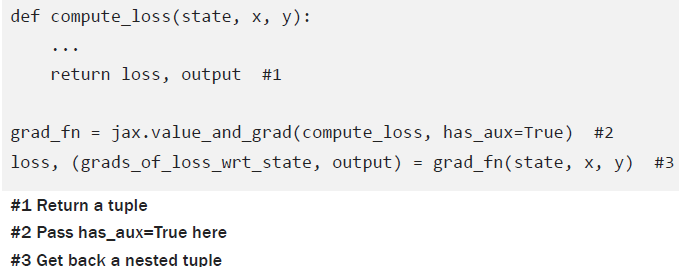

##### Making JAX functions fast with `@jax.jit`

One more thing. As a JAX user, you will frequently use the @jax.jit decorator, which
behaves identically to the @tf.function(jit_compile=True) decorator. It turns any
stateless JAX function into a XLA-compiled piece of code, typically delivering a considerable
execution speedup.

Be mindful that you can only decorate a stateless function (does not store or modify its internal state, output only depends on input) – any tensors that get updated
by the function should be part of its return values.

In [72]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: a linear classifier in pure JAX

Now you know enough JAX to write the JAX version of our linear classifier example. There
are two major differences with the TensorFlow and PyTorch versions you’ve already seen:
1. All functions we will create will be stateless. That means the state (the
arrays W and b) will be provided as function arguments, and if they get
modified by the function, their new value will be returned by the function.
2. Gradients are computed using the JAX value_and_grad() utility.

The model function and the mean squared error function should look familiar:

In [73]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In order to compute gradients, we need to package loss computation in a single
compute_loss() function. It returns the total loss as a scalar, and it takes state as its first
argument: a tuple of all the tensors we need gradients for.

In [74]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

Calling jax.value_and_grad() on this function gives us a new function, with the same
argument as compute_loss, which returns both the loss and the gradients of the loss with
regard to the elements of state.

In [75]:
grad_fn = jax.value_and_grad(compute_loss)

Next, we can set up our training step function. It looks straightforward. Be mindful that,
unlike its TensorFlow and PyTorch equivalents, it needs to be stateless, and so it must
return the updated values of the W and b tensors.

In [ ]:
learning_rate = 0.1

@jax.jit  # use XLA compilation
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)  # Compute the forward pass and backward pass in one go.
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate  # update W and b
    b = b - grad_wrt_b * learning_rate
    return loss, W, b  # return the new values of W and b in additon to the loss

Note that because we won’t change the learning_rate during our example, we can
consider it part of the function itself and not our model’s state. If we wanted to modify our
learning rate during training, we’d need to pass it through as well.

Finally, we’re ready to run the full training loop. We initialize W and b, and we repeatedly
update them via stateless calls to training_step().

In [77]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 3.5640
Loss at step 1: 0.2599
Loss at step 2: 0.1283
Loss at step 3: 0.1014
Loss at step 4: 0.0919
Loss at step 5: 0.0856
Loss at step 6: 0.0803
Loss at step 7: 0.0755
Loss at step 8: 0.0711
Loss at step 9: 0.0672
Loss at step 10: 0.0635
Loss at step 11: 0.0602
Loss at step 12: 0.0572
Loss at step 13: 0.0544
Loss at step 14: 0.0519
Loss at step 15: 0.0496
Loss at step 16: 0.0475
Loss at step 17: 0.0456
Loss at step 18: 0.0438
Loss at step 19: 0.0422
Loss at step 20: 0.0408
Loss at step 21: 0.0394
Loss at step 22: 0.0382
Loss at step 23: 0.0371
Loss at step 24: 0.0361
Loss at step 25: 0.0352
Loss at step 26: 0.0343
Loss at step 27: 0.0336
Loss at step 28: 0.0329
Loss at step 29: 0.0322
Loss at step 30: 0.0316
Loss at step 31: 0.0311
Loss at step 32: 0.0306
Loss at step 33: 0.0302
Loss at step 34: 0.0298
Loss at step 35: 0.0294
Loss at step 36: 0.0291
Loss at step 37: 0.0288
Loss at step 38: 0.0285
Loss at step 39: 0.0282


#### What makes the JAX approach unique

The main thing that makes JAX unique among modern machine learning frameworks is its
functional, stateless philosophy. While it may seem to cause friction at first, it is what
unlocks the power of JAX – its ability to compile to extremely fast code and to scale to
arbitrarily large models and arbitrarily many devices.

There’s a lot to like about JAX:

It’s fast. For most models, it is the fastest of all frameworks you’ve seen
so far.

Its numerical API is fully consistent with NumPy, making it pleasant to
learn.

It’s the best fit for training models on TPUs, as it was developed from the
ground up for XLA and TPUs.

Using JAX can also come with some amount of developer friction:

Its usage of metaprogramming and compilation can make it significantly
harder to debug compared to pure eager execution.

Low-level training loops tend to be more verbose and more difficult to
write than in TensorFlow or PyTorch.

At this point, you know the basics of TensorFlow, PyTorch, and JAX, and you can use these
frameworks to implement a basic linear classifier from scratch. That’s a solid foundation to
build upon. It’s now time to move on to a more productive path to deep learning: the Keras
API.

### Introduction to Keras

Keras is a deep-learning API for Python that provides a convenient way to define and train
any kind of deep-learning model. It was released in March 2015, with its V2 in 2017 and its
V3 in 2023.

Keras users range from academic researchers, engineers, and data scientists at both
startups and large companies, to graduate students and hobbyists. Keras is used at Google,
Netflix, Uber, YouTube, CERN, NASA, Yelp, Instacart, Square, Waymo, YouTube, and
thousands of smaller organizations working on a wide range of problems across every
industry. Your YouTube recommendations originate from Keras models. The Waymo selfdriving
cars rely on Keras models for processing sensor data. Keras is also a popular
framework on Kaggle, the machine-learning competition website.

Because Keras has a diverse user base, it doesn’t force you to follow a single “true” way
of building and training models. Rather, it enables a wide range of different workflows, from
the very high-level to the very low-level, corresponding to different user profiles. For
instance, you have an array of ways to build models and an array of ways to train them,
each representing a certain trade-off between usability and flexibility. In Chapter 7, we’ll
review in detail a good fraction of this spectrum of workflows.

#### First steps with Keras

##### Picking a backend framework

Keras can be used together with either JAX, TensorFlow, or PyTorch. They’re the
“backend frameworks” of Keras. Through these backend frameworks, Keras can run on top
of different types of hardware (see Figure 3.4) – GPU, TPU, or plain CPU – can be
seamlessly scaled to thousands of machines, and can be deployed to a variety of platforms.

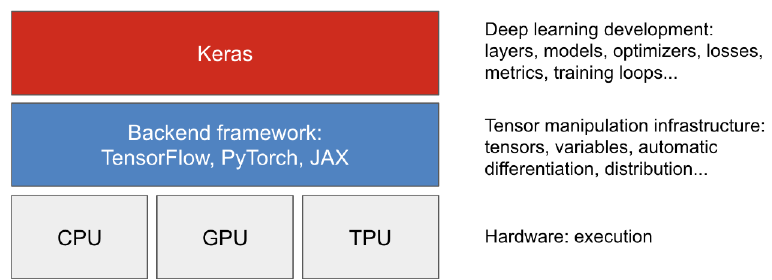

Backend frameworks are pluggable: you can switch to a different backend framework after
you’ve written some Keras code. You aren’t locked into a single framework and a single
ecosystem – you can move your models from JAX to TensorFlow to PyTorch depending on
your current needs. For instance, when you develop a Keras model, you could debug it with
PyTorch, train it on TPU with JAX for maximum efficiency, and finally run inference with the
excellent tooling from the TensorFlow ecosystem.

The default backend for Keras right now is TensorFlow, so if you run import keras in a
fresh environment, without having configured anything, you will be running on top of
TensorFlow. There are two ways to pick a different backend:

1. Set the environment variable KERAS_BACKEND. Before you start your
python repl, you can run the following shell command to use JAX as your
Keras backend: export KERAS_BACKEND=jax. Alternatively, you can add
the following code snippet at the top of your Python file or notebook (note
that it must imperatively go before the first import keras):

In [78]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

2. Edit your local Keras configuration file at ~/.keras/keras.json. If you
have already imported Keras once, then this file has already been created
with default settings. You can use any text editor to open and modify it –
it’s a human-readable JSON file. It should look like this:

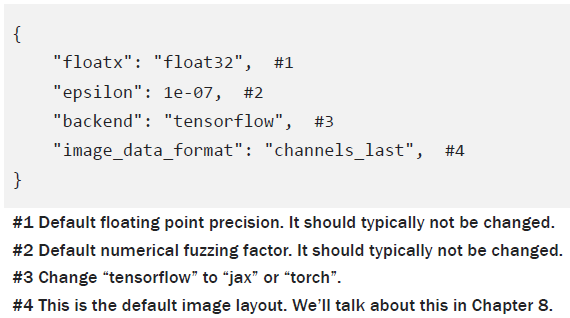

NOTE When configuring the Keras backend, you should use the string "torch" to refer to the
PyTorch backend, rather than the string "pytorch", which would be invalid. This is because the
PyTorch package name is torch (as in import torch or pip install torch).

Now, you may ask, which backend should I be picking? It’s really your own choice: all Keras
code examples in the rest of the book will be compatible with all three backends. If the
need for backend-specific code arises (as in Chapter 7, for instance), I will show you all
three versions – TensorFlow, PyTorch, JAX. If you have no particular backend preference,
my personal recommendation is JAX. It’s usually the most performant backend.

Once your backend is configured, you can start actually building and training Keras
models. Let’s take a look.

#### Layers: the building blocks of deep learning

The fundamental data structure in neural networks is the layer, to which you were
introduced in Chapter 2. A layer is a data-processing module that takes as input one or
more tensors and that outputs one or more tensors. Some layers are stateless, but more
frequently layers have a state: the layer’s weights, one or several tensors learned with
stochastic gradient descent, which together contain the network’s knowledge.

Different types of layers are appropriate for different tensor formats and different types
of data processing. For instance, simple vector data, stored in 2D tensors of shape
(samples, features), is often processed by densely connected layers, also called fully
connected or dense layers (the Dense class in Keras). Sequence data, stored in 3D tensors
of shape (samples, timesteps, features), is typically processed by recurrent layers,
such as an LSTM layer, or 1D convolution layers (Conv1D). Image data, stored in rank-4
tensors, is usually processed by 2D convolution layers (Conv2D).

You can think of layers as the LEGO bricks of deep learning, a metaphor that is made
explicit by Keras. Building deep-learning models in Keras is done by clipping together
compatible layers to form useful data-transformation pipelines.

##### The base `Layer` class in Keras

A simple API should have a single abstraction around which everything is centered. In
Keras, that’s the Layer class. Everything in Keras is either a Layer or something that
closely interacts with a Layer.

A Layer is an object that encapsulates some state (weights) and some computation (a
forward pass). The weights are typically defined in a build() (although they could also be
created in the constructor __init__()), and the computation is defined in the call()
method.

In the previous chapter, we implemented a NaiveDense class that contained two weights
W and b and applied the computation output = activation(matmul(input, W) + b). This
is what the same layer would look like in Keras:

In [ ]:
import keras

class SimpleDense(keras.Layer):   # all layers inherit from base layers class
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):  # weight creation happens here
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )  #3 add_weight is a shortcut method for creating weights. It’s also possible to create standalone variables and assign them as layer attributes, like: self.W = keras.Variable(shape=..., initializer=...).
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):   # forward pass
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

Once instantiated, a layer like this can be used just like a function, taking as input a
tensor:

In [ ]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)  # instantiate the layer
input_tensor = keras.ops.ones(shape=(2, 784))  # create input data
output_tensor = my_dense(input_tensor)  # call the layer on the inputs
print(output_tensor.shape)

(2, 32)


Now, you’re probably wondering, why did we have to implement call() and build(), since
we ended up using our layer by plainly calling it, that is to say, by using its __call__
method? It’s because we want to be able to create the state just in time. Let’s see how that
works.

##### Automatic shape inference: building layers on the fly

Just like with LEGO bricks, you can only “clip” together layers that are compatible. The
notion of layer compatibility here refers specifically to the fact that every layer will only
accept input tensors of a certain shape and will return output tensors of a certain shape. 

Consider the following example:

In [ ]:
from keras import layers

layer = layers.Dense(32, activation="relu")  # dense layer with 32 outputs (or 32 neurons)

This layer will return a tensor whose non-batch dimension is 32. It can only be connected
to a downstream layer that expects 32-dimensional vectors as its input.
When using Keras, you don’t have to worry about size compatibility most of the time,
because the layers you add to your models are dynamically built to match the shape of the
incoming inputs. For instance, suppose you write the following:

In [82]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

The layers didn’t receive any information about the shape of their inputs – instead, they
automatically inferred their input shape as being the shape of the first inputs they see.
In the toy version of a Dense layer that we’ve implemented in Chapter 2, we had to pass
the layer’s input size explicitly to the constructor in order to be able to create its weights.
That’s not ideal, because it would lead to models that look like this, where each new layer
needs to be made aware of the shape of the layer before it:

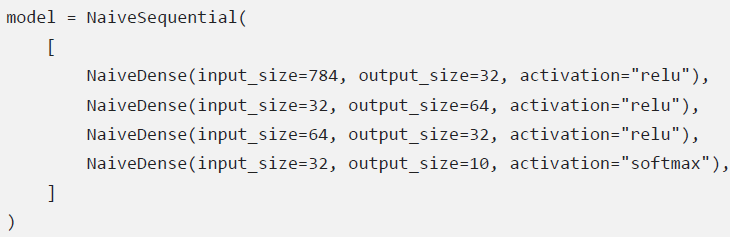

It would be even worse when the rules used by a layer to produce its output shape are
complex. For instance, what if our layer returned outputs of shape (batch, input_size *
2 if input_size % 2 == 0 else input_size * 3)?

If we were to reimplement our NaiveDense layer as a Keras layer capable of automatic
shape inference, it would look like the SimpleDense layer above, with its build() and
call() methods.

In the Keras SimpleDense, we no longer create weights in the constructor like in the
previous example, instead, we create them in a dedicated state-creation method build(),
which receives as argument the first input shape seen by the layer. The build() method is
called automatically the first time the layer is called (via its __call__() method). In fact,
that’s why we defined the computation in a separate call() method rather than in the
__call__() method directly! The __call__() method of the base layer schematically looks
like this:

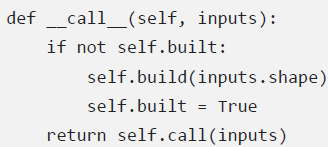

With automatic shape inference, our previous example becomes simple and neat:

In [83]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

Note that automatic shape inference is not the only thing that the Layer class’ __call__()
method handles. It takes care of many more things, in particular routing between eager
and graph execution, and input masking (which we cover in Chapter 14). For now, just
remember: when implementing your own layers, put the forward pass in the call()
method.

#### From layers to models

A deep-learning model is a graph of layers. In Keras, that’s the Model class. For now,
you’ve only seen Sequential models (a subclass of Model), which are simple stacks of
layers, mapping a single input to a single output. But as you move forward, you’ll be
exposed to a much broader variety of network topologies. Some common ones are:

Two-branch networks

Multihead networks

Residual connections

Network topology can get quite involved. For instance, this is the topology of the graph of
layers of a Transformer, a common architecture designed to process text data:

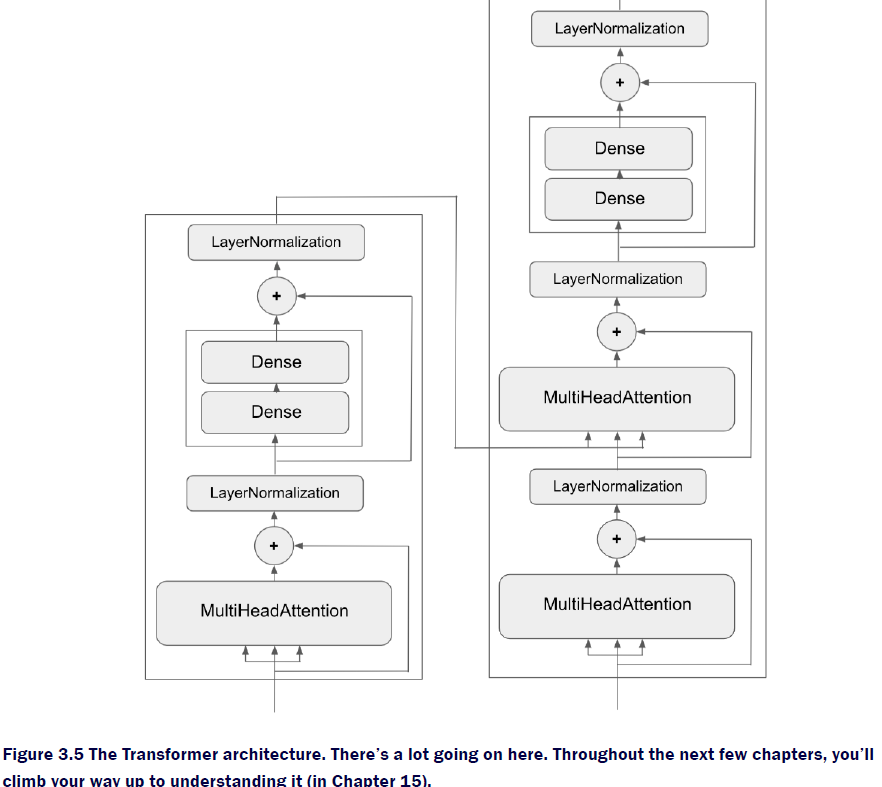

There are generally two ways of building such models in Keras: you could directly subclass
the Model class, or you could use the Functional API, which lets you do more with less
code. We’ll cover both approaches in Chapter 7.

The topology of a model defines a hypothesis space. You may remember that in Chapter
1, we described machine learning as “searching for useful representations of some input
data, within a predefined space of possibilities, using guidance from a feedback signal.” By
choosing a network topology, you constrain your space of possibilities (hypothesis space) to
a specific series of tensor operations, mapping input data to output data. What you’ll then
be searching for is a good set of values for the weight tensors involved in these tensor
operations.

To learn from data, you have to make assumptions about it. These assumptions define
what can be learned. As such, the structure of your hypothesis space – the architecture of
your model – is extremely important. It encodes the assumptions you make about your
problem, the prior knowledge that the model starts with. For instance, if you’re working on
a two-class classification problem with a model made of a single Dense layer with no
activation (a pure affine transformation), you are assuming that your two classes are
linearly separable.

Picking the right network architecture is more an art than a science; and although there
are some best practices and principles you can rely on, only practice can help you become a
proper neural-network architect. The next few chapters will both teach you explicit
principles for building neural networks and help you develop intuition as to what works or
doesn’t work for specific problems. You’ll build a solid intuition about what type of model
architectures work for different kinds of problems, how to build these networks in practice,
how to pick the right learning configuration, and how to tweak a model until it yields the
results you want to see.

#### The "compile" step: configuring the learning process

Once the model architecture is defined, you still have to choose three more things:

Loss function (objective function) – The quantity that will be
minimized during training. It represents a measure of success for the task
at hand.

Optimizer – Determines how the network will be updated based on the
loss function. It implements a specific variant of stochastic gradient
descent (SGD).

Metrics – The measures of success you want to monitor during training
and validation, such as classification accuracy. Unlike the loss, training
will not optimize directly for these metrics. As such, metrics don’t need to
be differentiable.

Once you’ve picked your loss, optimizer, and metrics, you can use the built-in compile()
and fit() methods to start training your model. Alternatively, you could also write your
own custom training loops – we cover how to do this in Chapter 7. It’s a lot more work! For
now, let’s take a look at compile() and fit().

The compile() method configures the training process – you’ve already been introduced
to it in your very first neural network example in Chapter 2. It takes the arguments
optimizer, loss, and metrics (a list):

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])  # one neuron linear classifier
model.compile(
    optimizer="rmsprop",  # optimizer is RMSprop
    loss="mean_squared_error",  # loss function is mean squared error
    metrics=["accuracy"],  # metric to monitor is accuracy.  The model is not optimizing to accuracy, it is optimizing to the loss: MSE
)

In the above call to compile(), we passed the optimizer, loss, and metrics as strings (such
as "rmsprop"). These strings are actually shortcuts that get converted to Python objects.
For instance, "rmsprop" becomes keras.optimizers.RMSprop(). Importantly, it’s also
possible to specify these arguments as object instances, like this:

In [85]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

This is useful if you want to pass your own custom losses or metrics, or if you want to
further configure the objects you’re using – for instance, by passing a learning_rate
argument to the optimizer:

model.compile(
optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
loss=my_custom_loss,
metrics=[my_custom_metric_1, my_custom_metric_2],
)

In Chapter 7, we cover how to create custom losses and metrics. In general, you won’t
have to create your own losses, metrics, or optimizers from scratch, because Keras offers a
wide range of built-in options that is likely to include what you need:

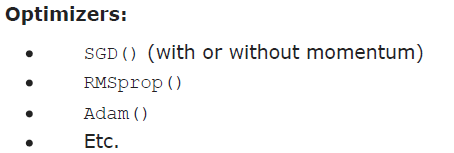
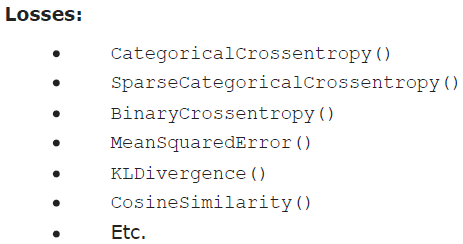
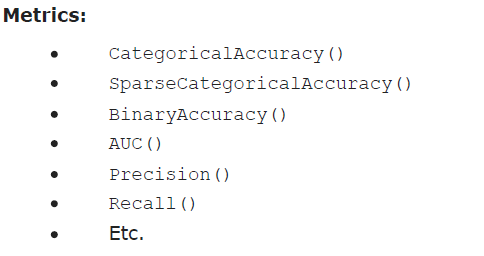

#### Picking a loss function

Choosing the right loss function for the right problem is extremely important: your network
will take any shortcut it can to minimize the loss; so if the objective doesn’t fully correlate
with success for the task at hand, your network will end up doing things you may not have
wanted. Imagine a stupid, omnipotent AI trained via SGD, with this poorly chosen objective
function: “maximizing the average well-being of all humans alive.” To make its job easier,
this AI might choose to kill all humans except a few and focus on the well-being of the
remaining ones – because average well-being isn’t affected by how many humans are left.
That might not be what you intended! Just remember that all neural networks you build will
be just as ruthless in lowering their loss function – so choose the objective wisely, or you’ll
have to face unintended side effects.

Fortunately, when it comes to common problems such as classification, regression, and
sequence prediction, there are simple guidelines you can follow to choose the correct loss.
For instance, you’ll use binary crossentropy for a two-class classification problem,
categorical crossentropy for a many-class classification problem, and so on. Only when
you’re working on truly new research problems will you have to develop your own loss
functions. In the next few chapters, we’ll detail explicitly which loss functions to choose for
a wide range of common tasks.

#### Understanding the `fit` method

After compile() comes fit(). The fit method implements the training loop itself. Its key
arguments are:

The data (inputs and targets) to train on. It will typically be passed either
in the form of NumPy arrays, or a TensorFlow Dataset object. You’ll learn
more about the Dataset API in the next chapters.
The number of epochs to train for: how many times the training loop
should iterate over the data passed.

The batch size to use within each epoch of mini-batch gradient descent:
the number of training examples considered to compute the gradients for
one weight update step.

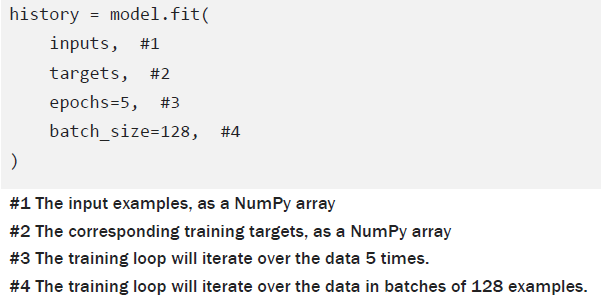

The call to fit returns a History object. This object contains a history field which is a dict
mapping keys such as "loss" or specific metric names to the list of their per-epoch values.

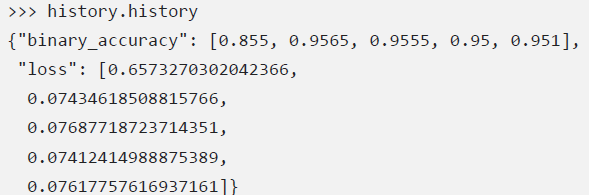

In [86]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - binary_accuracy: 0.9840 - loss: 4.4661
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9835 - loss: 4.2227 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9830 - loss: 4.0173
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9825 - loss: 3.8210
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9825 - loss: 3.6322


In [87]:
history.history

{'binary_accuracy': [0.984000027179718,
  0.983500063419342,
  0.9830000400543213,
  0.9825000762939453,
  0.9825000762939453],
 'loss': [4.466116428375244,
  4.222721099853516,
  4.017324447631836,
  3.8209590911865234,
  3.6322219371795654]}

#### Monitoring loss & metrics on validation data

The goal of machine learning is not to obtain models that perform well on the training data
– which is easy, all you have to do is follow the gradient. The goal is to obtain models that
perform well in general, in particular on data points that the model has never encountered
before. Just because a model performs well on its training data doesn’t mean it will perform
well on data it has never seen! For instance, it’s possible that your model could end up
merely memorizing a mapping between your training samples and their targets, which
would be useless for the task of predicting targets for data the model has never seen
before. We’ll go over this point in much more detail in the Chapter 5.

To keep an eye on how the model does on new data, it’s standard practice to reserve a
subset of the training data as “validation data”: you won’t be training the model on this
data, but you will use it to compute a loss value and metrics value. You do this by using the
validation_data argument in fit(). Like the training data, the validation data could be
passed as NumPy arrays or as a TensorFlow Dataset object.

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))  # shuffle data so we don't have one data type in validation set
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))  # 30% of data for validation
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.9236 - loss: 0.1204 - val_binary_accuracy: 0.9950 - val_loss: 0.0385
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9507 - loss: 0.0713 - val_binary_accuracy: 0.9767 - val_loss: 0.1240
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9579 - loss: 0.0769 - val_binary_accuracy: 0.9950 - val_loss: 0.0489
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9507 - loss: 0.0787 - val_binary_accuracy: 0.9467 - val_loss: 0.1531
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9579 - loss: 0.0720 - val_binary_accuracy: 0.9600 - val_loss: 0.1103


The value of the loss on the validation data is called the “validation loss”, to distinguish it
from the “training loss”. Note that it’s essential to keep the training data and validation data
strictly separate: the purpose of validation is to monitor whether what the model is learning
is actually useful on new data. If any of the validation data has been seen by the model
during training, your validation loss and metrics will be flawed.
Note that if you want to compute the validation loss and metrics after training is
complete, you can call the evaluate method:

loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)

evaluate() will iterate in batches (of size batch_size) over the data passed, and return a
list of scalars, where the first entry is the validation loss and the following entries are the
validation metrics. If the model has no metrics, only the validation loss is returned (rather
than a list).

#### Inference: using a model after training

Once you’ve trained your model, you’re going to want to use it to make predictions on new
data. This is called “inference.” To do this, a naive approach would simply be to __call__
the model:

predictions = model(new_inputs)

However, this will process all inputs in new_inputs at once, which may not be feasible if
you’re looking at a lot of data (in particular, it may require more memory than your GPU
has).
A better way to do inference is to use the predict() method. It will iterate over the data
in small batches, and return a NumPy array of predictions. And unlike __call__, it can also
process TensorFlow Dataset objects.

For instance, if we use predict() on some of our validation data with the linear model we
trained earlier, we get scalar scores that correspond to the model’s prediction for each input
sample.

For now, this is all you need to know about Keras models. At this point, you are ready to
move on to solving real-world machine problems with Keras, in the next chapter.

In [89]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[0.704836  ]
 [0.32337627]
 [1.3556864 ]
 [0.23597443]
 [1.1013556 ]
 [0.06152391]
 [1.2265425 ]
 [1.3324535 ]
 [1.0554662 ]
 [0.2607528 ]]


### Chapter summary

TensorFlow, PyTorch, and JAX are three popular low-level frameworks for
numerical computation and autodifferentiation. They all have their own
way of doing things, their own strengths and weaknesses.

Keras is a high-level API for building and training neural networks. It can
be used with either TensorFlow, PyTorch, or JAX – just pick the backend
you like best.

The central class of Keras is the Layer. A layer encapsulates some
weights and some computation. Layers are assembled into models.
Before you start training a model, you need to pick an optimizer, a loss,
and some metrics, which you specify via the model.compile() method.
To train a model, you can use the fit() method, which runs mini-batch
gradient descent for you. You can also use it to monitor your loss and
metrics on “validation data”, a set of inputs that the model doesn’t see
during training.

Once your model is trained, use the model.predict() method to
generate predictions on new inputs.

[1] Note that PyTorch is a bit of an intermediate case: while it is mainly a lower-level
framework, it also includes its own layers and its own optimizers. However, if you
use PyTorch in conjunction with Keras, then you will only interact with low-level
PyTorch APIs such as tensor operations.

# basic model parameter table:
Note, if using one hot encoded labels, use categorical_crossentropy.  If using integer enceded labels, use sparse_categorical_crossentropy.

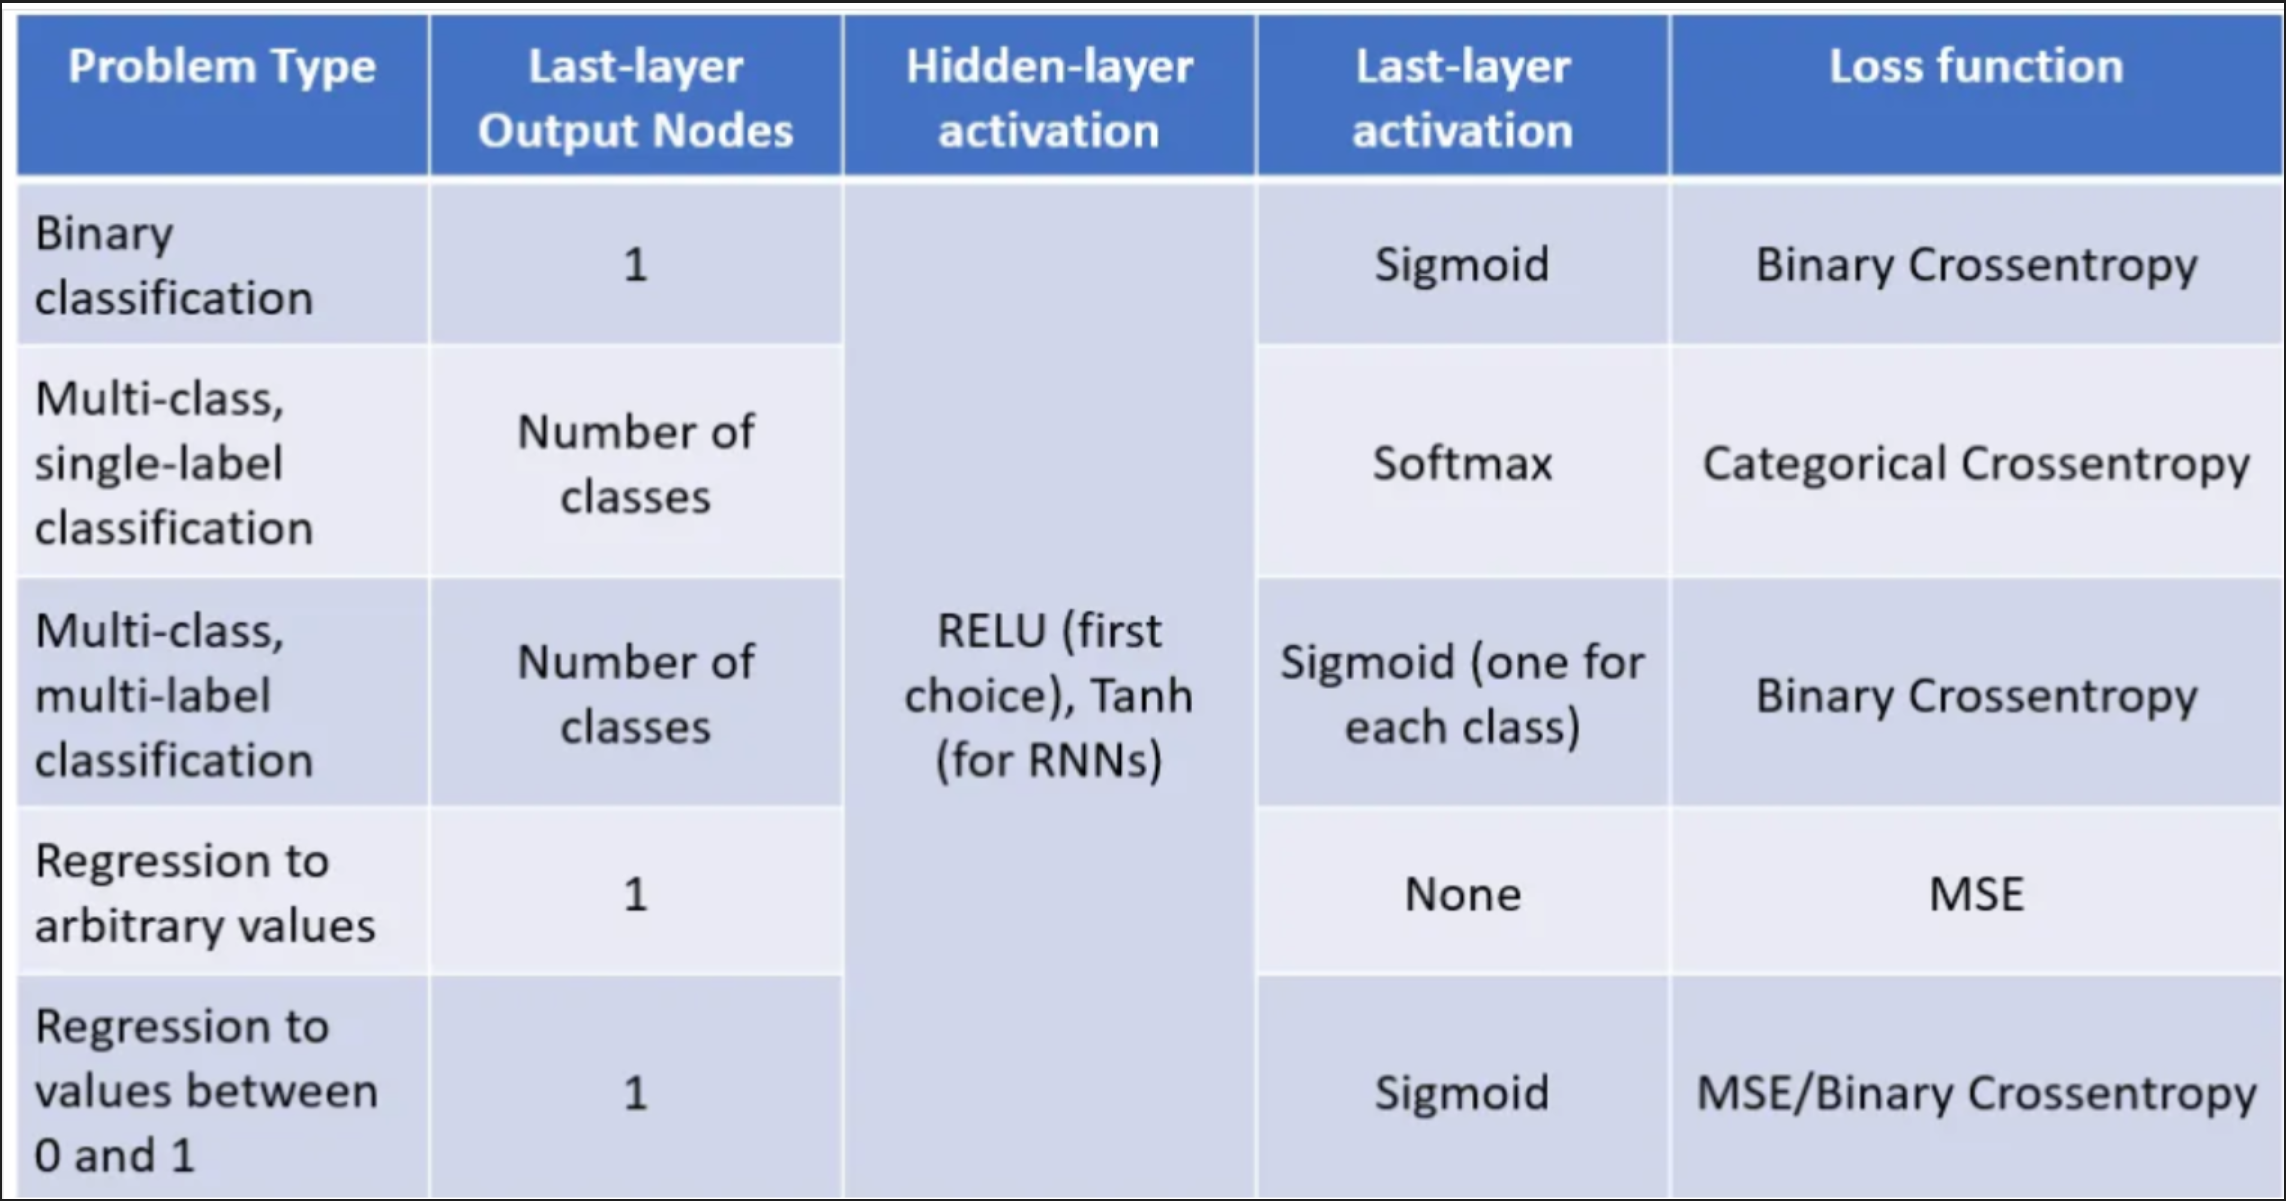